# Your First Diffraction Model
This tutorial covers the basic useage of `dygdug` as an object-oriented front-end to the `prysm` optical propagator.

## Pupil-plane Optics
Pupil-plane optics are represented with the `Pupil` object. This class broadly accepts any pre-generated data and sample size, but for the purposes of this tutorial, we will focus on the alternative constructors for these objects. A simple, circular aperture can be defined using the following `.circle` constructor

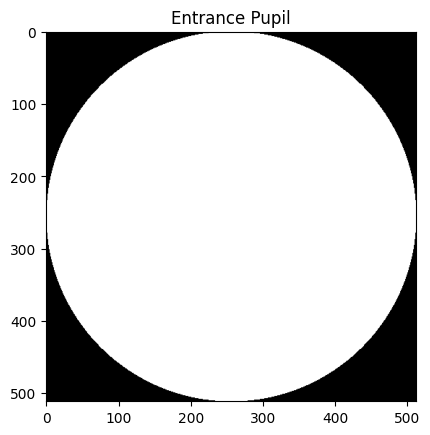

In [5]:
from dygdug.masks import Pupil
import matplotlib.pyplot as plt

# Define sampling Parameters
Dpup = 10_000 # mm, diameter
Npup = 512    # samples

circ_ap = Pupil.circle(Dpup=Dpup, Npup=Npup)

plt.figure()
plt.title("Entrance Pupil")
plt.imshow(circ_ap.data, cmap="gray")
plt.show()


Some systems, like astronomical telescopes, have a secondary mirror in front of the primary mirror, which results in an annular entrance pupil. We also have the `.annular` constructor to support this

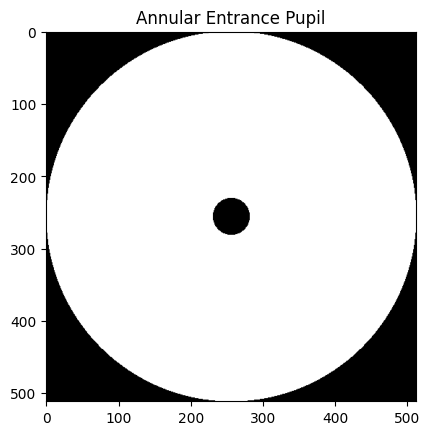

In [6]:
annular_ap = Pupil.annular(
    Dpup=Dpup, # defines array size
    Npup=Npup, # defines array sampling
    inner_radius=0.1 * Dpup / 2,
    outer_radius=Dpup / 2
)

plt.figure()
plt.title("Annular Entrance Pupil")
plt.imshow(annular_ap.data, cmap="gray")
plt.show()

`prysm` is well-known for its fast hexagonal mirror generation, so we made sure to add compatibility for defining segmented apertures using `dygdug`'s object-oriented interfact. This capability is accessed via the `.hexagonal_segmented` constructor.

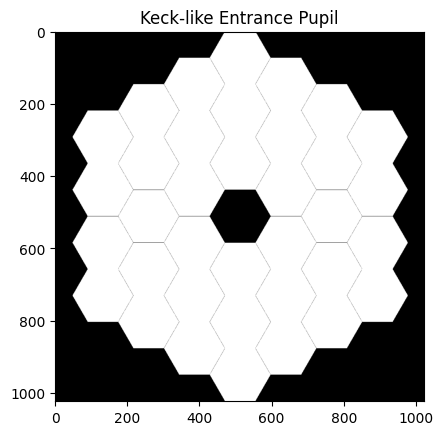

In [16]:
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT

seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800

hexagonal_ap = Pupil.hexagonal_segmented(
    Dpup=10.95e3,              # defines array size
    Npup=1024,                 # defines array sampling
    rings=3,                   # rings of hexagonal sub-apertures
    segment_diameter=seg_diam, # the flat_to_flat distance
    segment_separation=5,      # the gap in between segments
    exclude=(0,)               # which segment ID to exclude
)

plt.figure()
plt.title("Keck-like Entrance Pupil")
plt.imshow(hexagonal_ap.data, cmap="gray")
plt.show()

## Focal-plane Optics
Focal-plane optics are represented with the `FPM` object. Unlike a `Pupil`, an `FPM` is not stored as a static array. Coronagraphic masks are frequently wavelength-dependent (the same physical mask subtends a different number of $\lambda/D$ at each wavelength), so an `FPM` instead wraps a *function of wavelength*. Calling an `FPM` instance with a wavelength returns the complex mask array sampled on its grid:

```python
fpm = FPM.lyot(...)
mask = fpm(wvl)   # evaluate the mask at a given wavelength
```

Internally this function is wrapped in a `WavelengthDependentFunctionCache`, so repeated evaluations at the same wavelength are returned from a cache rather than recomputed.

Image-plane sampling is specified in units of $\lambda/D$ rather than physical distance. The constructors take `N` (samples per side), `lamD` (the physical size of one $\lambda/D$), and `px_per_lamD` (the resolution, i.e. how many samples span one $\lambda/D$); the intersample spacing is then `dx = lamD / px_per_lamD`.

As with `Pupil`, the most convenient way to build an `FPM` is through its alternative constructors.

In [2]:
from dygdug.masks import FPM

The classic hard-edged Lyot coronagraph uses an opaque circular spot at the center of the focal plane to block on-axis starlight. The `.lyot` constructor builds exactly this: the mask is transmissive (value 1) everywhere except inside a disk of the given `radius` (in $\lambda/D$), where it is opaque (value 0).

In [ ]:
# Define image-plane sampling parameters shared by the masks below
Nfpm = 512        # samples per side
lamD = 1.0        # physical size of one lambda/D (arbitrary units here)
px_per_lamD = 8   # resolution: samples per lambda/D
wvl = 0.55        # wavelength at which to evaluate the mask

lyot_fpm = FPM.lyot(
    N=Nfpm,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    radius=3,  # radius of the opaque spot, in lambda/D
)

plt.figure()
plt.title("Lyot Focal Plane Mask")
plt.imshow(lyot_fpm(wvl), cmap="gray")
plt.colorbar()
plt.show()

The `.annular` constructor builds a mask that transmits only within an annulus, defined by an `inner_radius` and `outer_radius` (both in $\lambda/D$). This is the complement of the Lyot spot — light is blocked everywhere except the ring between the two radii — and is convenient for isolating a particular angular region of the image plane.

In [ ]:
annular_fpm = FPM.annular(
    N=Nfpm,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,   # lambda/D
    outer_radius=10,  # lambda/D
)

plt.figure()
plt.title("Annular Focal Plane Mask")
plt.imshow(annular_fpm(wvl), cmap="gray")
plt.colorbar()
plt.show()

Finally, the `.unity` constructor produces a fully transmissive mask of all ones. This is useful as a "no mask" placeholder when you want to propagate through the coronagraph architecture without a focal-plane mask in place — for example, to compute the off-axis (planet) point-spread function or a reference unocculted image.

In [ ]:
unity_fpm = FPM.unity(N=Nfpm, lamD=lamD, px_per_lamD=px_per_lamD)

plt.figure()
plt.title("Unity Focal Plane Mask")
plt.imshow(unity_fpm(wvl), cmap="gray")
plt.colorbar()
plt.show()